# Synthetic-noise verification

Inspects representative surrogate windows generated by `synth_noise` and their relation to the original event records.


In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path(r"M:\Github\TFM_SeismicPhasePicker_ColombianAndesRegion")
sys.path.insert(0, str(REPO_ROOT / "src" / "preprocessing"))
sys.path.insert(0, str(REPO_ROOT / "src" / "labeling"))

import preprocessing_utils as pp
import consensus_utils as cu

print(f"NPTS = {pp.NPTS} (150 s @ 100 Hz)")
_kw = cu.synth_noise.__kwdefaults__
print(f"Tramo sintético: muestras {_kw['pre_a']}:{_kw['pre_b']} "
      f"= {_kw['pre_a']/100}s a {_kw['pre_b']/100}s")

NPTS = 15001 (150 s @ 100 Hz)
Tramo sintético: muestras 200:2700 = 2.0s a 27.0s


In [3]:
# Load one accepted event window for inspection.
STATION = "ZAR"
TIMESTAMP = "2018.071.03.24.56"  # example with P and S labels

station_dir = REPO_ROOT / "data" / "raw" / "waveforms" / STATION
arr = pp.load_window_array(station_dir, TIMESTAMP, STATION, preprocess=True)
print(f"Ventana cargada: {arr.shape}, dtype={arr.dtype}")
print(f"P muestra ~2978 (29.78 s), S muestra ~5659 (56.59 s)")

Ventana cargada: (3, 15001), dtype=float32
P muestra ~2978 (29.78 s), S muestra ~5659 (56.59 s)


In [4]:
# Generate a surrogate with the dataset helper.
rng = np.random.default_rng(42)
n_out = pp.NPTS  # 15001
syn = cu.synth_noise(arr, n_out, rng=rng)
print(f"Sintética: {syn.shape}, dtype={syn.dtype}")
print(f"std original: {arr.std():.5f} | std sintética: {syn.std():.5f}")
print(f"rms original: {np.sqrt((arr**2).mean()):.5f} | rms sintética: {np.sqrt((syn**2).mean()):.5f}")

Sintética: (3, 15001), dtype=float32
std original: 186.12262 | std sintética: 46.35714
rms original: 186.12416 | rms sintética: 46.35714


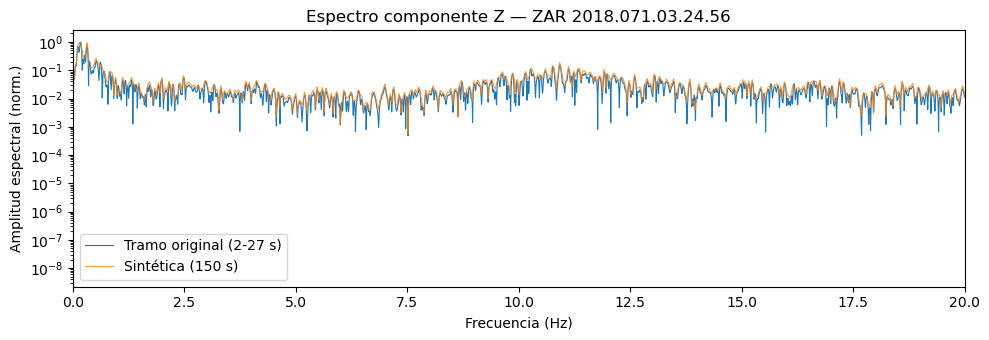

In [5]:
# Compare source-segment and surrogate spectra.
seg = arr[0, 200:2700]
f = np.fft.rfftfreq(n_out, 1 / 100.0)
amp_syn = np.abs(np.fft.rfft(syn[0]))
amp_seg = np.abs(np.fft.rfft(seg, n=n_out))

fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.semilogy(f, amp_seg / amp_seg.max(), lw=0.8, label="Tramo original (2-27 s)")
ax.semilogy(f, amp_syn / amp_syn.max(), lw=0.8, alpha=0.8, label="Sintética (150 s)")
ax.set_xlim(0, 20)
ax.set_xlabel("Frecuencia (Hz)")
ax.set_ylabel("Amplitud espectral (norm.)")
ax.set_title(f"Espectro componente Z — {STATION} {TIMESTAMP}")
ax.legend()
plt.tight_layout()
plt.show()

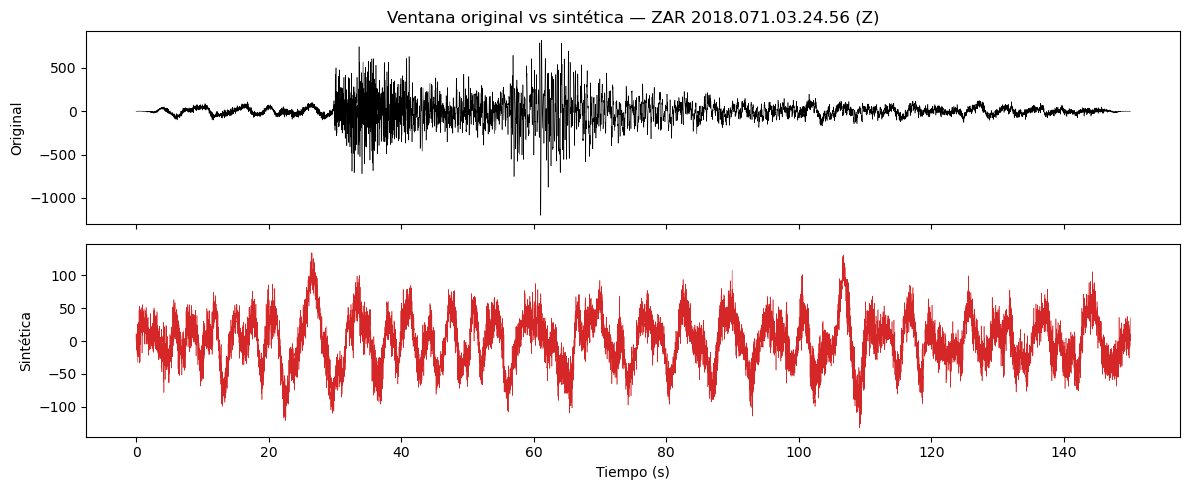

In [6]:
# Compare original and surrogate vertical components.
t = np.arange(n_out) / 100.0

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t, arr[0], lw=0.4, color="k")
axes[0].set_ylabel("Original")
axes[0].set_title(f"Ventana original vs sintética — {STATION} {TIMESTAMP} (Z)")
axes[1].plot(t, syn[0], lw=0.4, color="tab:red")
axes[1].set_ylabel("Sintética")
axes[1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

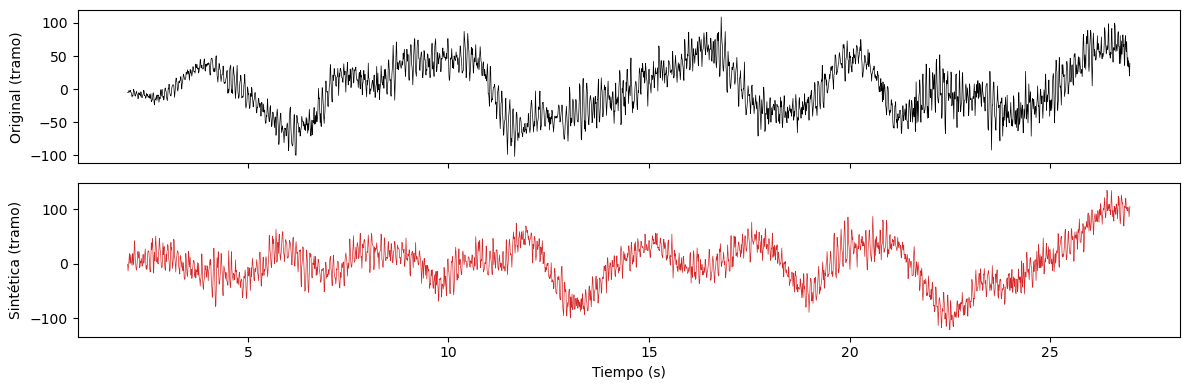

In [7]:
# Inspect the source interval and its surrogate counterpart.
fig, axes = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
axes[0].plot(t[200:2700], arr[0, 200:2700], lw=0.5, color="k")
axes[0].set_ylabel("Original (tramo)")
axes[1].plot(t[200:2700], syn[0, 200:2700], lw=0.5, color="tab:red")
axes[1].set_ylabel("Sintética (tramo)")
axes[1].set_xlabel("Tiempo (s)")
plt.tight_layout()
plt.show()

In [8]:
# Compare RMS near the accepted P arrival in this example.
# Elevated surrogate energy near P warrants closer inspection.
win = slice(2800, 3200)  # 28-32 s
e_orig = np.sqrt((arr[0, win] ** 2).mean())
e_syn = np.sqrt((syn[0, win] ** 2).mean())
e_seg = np.sqrt((seg ** 2).mean())
print(f"RMS original en 28-32 s (zona P real): {e_orig:.5f}")
print(f"RMS sintética en 28-32 s:              {e_syn:.5f}")
print(f"RMS tramo de origen (2-27 s):          {e_seg:.5f}")
print()
print(f"La sintética en la zona de la P tiene {e_syn/e_seg:.1%} de la energía del tramo de origen")
print(f"La original en la zona de la P tiene   {e_orig/e_seg:.1%} de la energía del tramo de origen")

RMS original en 28-32 s (zona P real): 130.85892
RMS sintética en 28-32 s:              50.50917
RMS tramo de origen (2-27 s):          37.98749

La sintética en la zona de la P tiene 133.0% de la energía del tramo de origen
La original en la zona de la P tiene   344.5% de la energía del tramo de origen


## Interpretation

Compare the source segment and surrogate spectra, waveform texture, and RMS near the P time. These checks flag unusual energy, but a single example does not establish that every surrogate is arrival-free.